In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# WHAT IS PCA?
# Principal Component Analysis (PCA) is a dimensionality reduction technique.
# "Dimensionality" = the number of features in your dataset.
# High-dimensional data is hard to visualize, slow to train on, and often
# contains lots of redundancy (correlated features that carry the same info).
#
# PCA finds new axes — called "principal components" (PCs) — that capture
# the directions of maximum variance in the data. It then projects (squishes)
# all the data onto a smaller number of these axes.
#
# Analogy: imagine a cloud of points in 3D space that mostly lies flat on a
# tilted plane. PCA finds that plane and lets you describe every point with
# just 2 coordinates (the plane's 2 axes) instead of 3. You lose a tiny bit
# of info (the slight thickness of the cloud) but gain a much simpler picture.
#
# Key guarantee: the first PC captures the MOST variance, the second PC
# captures the next most (orthogonal to the first), and so on. So when you
# keep only the top N components, you keep the most informative dimensions.

# 1. LOAD DATA
# load_digits returns 1797 handwritten digit images (0–9).
# Each image is 8×8 pixels = 64 pixel values = 64 features.
# Our goal: compress 64 features down to far fewer, with minimal info loss.
digits = load_digits()
X, y = digits.data, digits.target
print(X.shape)        # (1797, 64) → 1797 images, each with 64 features

# 2. SCALE (required before PCA)
# PCA finds the directions of maximum VARIANCE. If one feature has range
# 0–255 (pixel intensity) and another has range 0–1, the large-range feature
# will appear to have much more variance just because of its scale — not
# because it's more informative. Scaling (mean=0, std=1) gives each feature
# an equal chance to contribute to the principal components.
# Rule: always StandardScale before PCA.
X_scaled = StandardScaler().fit_transform(X)

# 3. FIT PCA WITH ALL COMPONENTS
# By calling PCA() with no arguments, we compute ALL 64 principal components.
# We're not reducing yet — we're just inspecting how much variance each
# component captures, so we can make an informed decision about how many to keep.
pca_full = PCA().fit(X_scaled)

# explained_variance_ratio_: an array of 64 numbers. Each number is the
# fraction of total variance captured by that principal component.
# They are sorted in descending order — PC1 is always the most informative.
ratios     = pca_full.explained_variance_ratio_

# np.cumsum gives the running total: cumulative[i] = sum of ratios[0..i].
# cumulative[9] tells you "how much variance do the top 10 PCs capture together?"
cumulative = np.cumsum(ratios)

print("PC1 alone:", round(ratios[0]*100, 1), "%")
print("PC1 + PC2:", round(cumulative[1]*100, 1), "%")

# np.argmax returns the index of the first value that meets the condition.
# +1 converts from 0-based index to a count (e.g., index 39 → 40 components).
n_95 = np.argmax(cumulative >= 0.95) + 1
print("Components needed for 95% variance:", n_95)
# Result: ~40 components capture 95% of the variance — down from 64.
# We can drop 24 features and keep almost all the information!

(1797, 64)
PC1 alone: 12.0 %
PC1 + PC2: 21.6 %
Components needed for 95% variance: 40


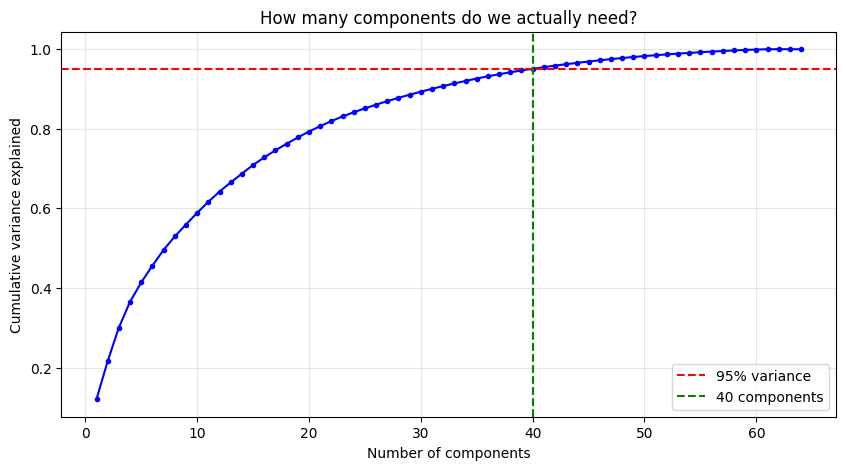

In [2]:
# 4. THE SCREE PLOT (variance-explained curve)
# This is the standard chart for deciding how many PCs to keep.
#
# X-axis: number of principal components included (1, 2, 3, ..., 64).
# Y-axis: cumulative fraction of total variance captured.
#
# Reading the chart:
#   - The curve rises steeply at first (early PCs carry most info).
#   - Then it flattens (later PCs add diminishing returns — mostly noise).
#   - Pick the number of components where the curve crosses your target
#     (e.g., 95% line in red). That's your compression target.
#
# This is analogous to the "elbow method" in K-Means — you're looking for
# the point of diminishing returns.

plt.figure(figsize=(10, 5))

# cumulative is an array of 64 values; range(1, 65) gives the x-axis labels.
plt.plot(range(1, len(cumulative)+1), cumulative, 'b-', marker='.')

# Red dashed line at 95% — a common threshold (keeps most info, cuts noise).
plt.axhline(0.95, color='r', ls='--', label='95% variance')

# Green dashed line at the exact number of components that hits 95%.
plt.axvline(n_95,  color='g', ls='--', label=f'{n_95} components')

plt.xlabel('Number of components')
plt.ylabel('Cumulative variance explained')
plt.title('How many components do we actually need?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

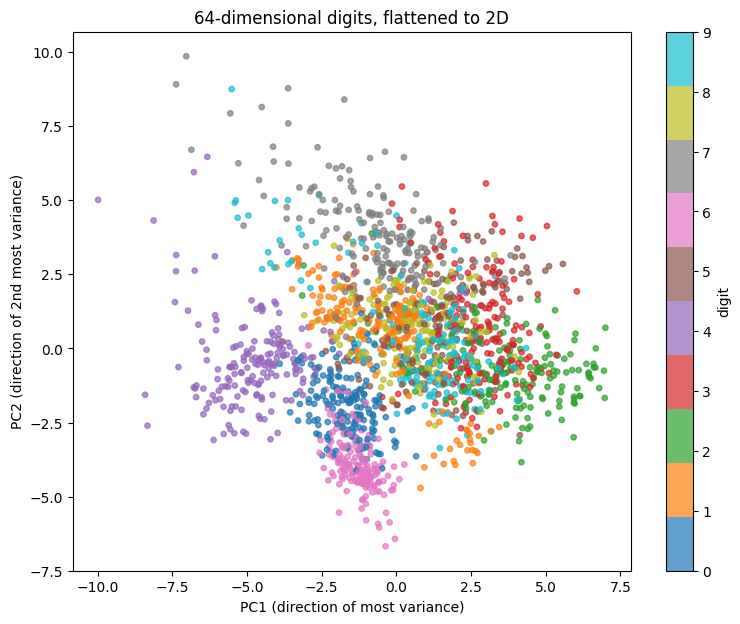

In [3]:
# 5. PROJECT 64-D → 2-D FOR VISUALIZATION
# We can't plot 64-dimensional data directly. PCA lets us project it down
# to 2 dimensions — the two directions that capture the most variance —
# so we can make a scatter plot and SEE the structure.
#
# Important caveat: 2 PCs only capture ~21% of the variance here.
# That means 79% of the information is lost in this plot.
# It's useful for a rough visual check, NOT for making final decisions.
# For actual compression, we'd keep 40 components (95% variance).

# n_components=2 tells PCA to keep only the top 2 principal components.
# fit_transform does fitting and projection in one step.
X_2d = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(9, 7))

# c=y colors each point by its digit label (0–9).
# cmap='tab10' gives 10 visually distinct colors — one per digit.
# alpha=0.7 makes overlapping points semi-transparent so we can see density.
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=15, alpha=0.7)

# Colorbar maps the color gradient to digit labels.
plt.colorbar(sc, label='digit')
plt.xlabel('PC1 (direction of most variance)')
plt.ylabel('PC2 (direction of 2nd most variance)')
plt.title('64-dimensional digits, flattened to 2D')
plt.show()

# WHAT TO LOOK FOR IN THIS PLOT:
# Tight, well-separated color clusters → digits that are visually distinct.
# Overlapping clusters → digits that look similar (e.g., 3 and 8, 4 and 9).
# Even with only 21% of variance, you can often see meaningful structure!

In [4]:
# 6. ACTUAL COMPRESSION FOR DOWNSTREAM USE
# Now we apply PCA for real — not just for visualization but to create
# a smaller feature matrix that a classifier (e.g., SVM, XGBoost) can
# train on faster without sacrificing much accuracy.
#
# n_components=0.95 is a special sklearn shorthand meaning:
#   "automatically choose the minimum number of components needed to
#    retain 95% of the total variance."
# You don't have to look up n_95 manually — sklearn figures it out.
#
# When to use PCA before a classifier:
#   ✓ Training is too slow due to many features
#   ✓ Features are highly correlated (e.g., adjacent pixels)
#   ✓ You want to reduce overfitting by cutting noise dimensions
#   ✗ When interpretability matters (PCs are abstract combinations of features)
#   ✗ When features are already independent and meaningful on their own

pca = PCA(n_components=0.95)           # keep enough PCs for 95% variance
X_reduced = pca.fit_transform(X_scaled)

print(X_reduced.shape)                 # (1797, 40) — 64 features → 40

# X_reduced is what you'd pass to a downstream model instead of X_scaled.
# You've cut 37% of the features (64 → 40) while keeping 95% of the signal.
# At prediction time, apply the SAME fitted pca.transform() to new data
# (just like scaler.transform) — do NOT refit on new data.

(1797, 40)
